In [5]:
import numpy as np
import matplotlib.pyplot as plt
from SphereGenerator import CameraSettings, CelestialBody, render_celestial_body


In [8]:

# Example camera intrinsics K = [[fx, 0, cx], [0, fy, cy], [0, 0, 1]]
width = 1280
height = 720
fx = 1120.0
fy = 1120.0
cx = width / 2.0
cy = height / 2.0
K = np.array(
    [
        [fx, 0.0, cx],
        [0.0, fy, cy],
        [0.0, 0.0, 1.0],
    ],
    dtype=np.float64,
)

camera = CameraSettings(
    width=width,
    height=height,
    horizontal_fov_deg=None,
    position_world=np.array([300.0, 0.0, 4_000_000.0]),
    forward_world=np.array([0.0, 0.0, -1.0]),
    up_world=np.array([0.0, 1.0, 0.0]),
    k_matrix=K,
)

moon_like = CelestialBody(
    center_world=np.array([0.0, 0.0, 0.0]),
    radius=1_737_400.0,
    albedo_rgb=(185, 185, 180),
)

result = render_celestial_body(
    camera=camera,
    body=moon_like,
    background_rgb=(8, 10, 18),
    light_direction_world=np.array([1.0, 0.2, 0.6]),
    ambient=0.1,
    diffuse_strength=0.9,
    limb_darkening_strength=0.4,
)

print(f"Angular diameter: {result.angular_diameter_deg:.3f} deg")
print(f"Center px: ({result.center_px[0]:.2f}, {result.center_px[1]:.2f})")
print(f"Projected radii: x={result.radius_px_x:.2f}px, y={result.radius_px_y:.2f}px")
print(f"Image shape: {result.image.shape}")

Angular diameter: 51.488 deg
Center px: (639.92, 360.00)
Projected radii: x=540.08px, y=540.08px
Image shape: (720, 1280, 3)


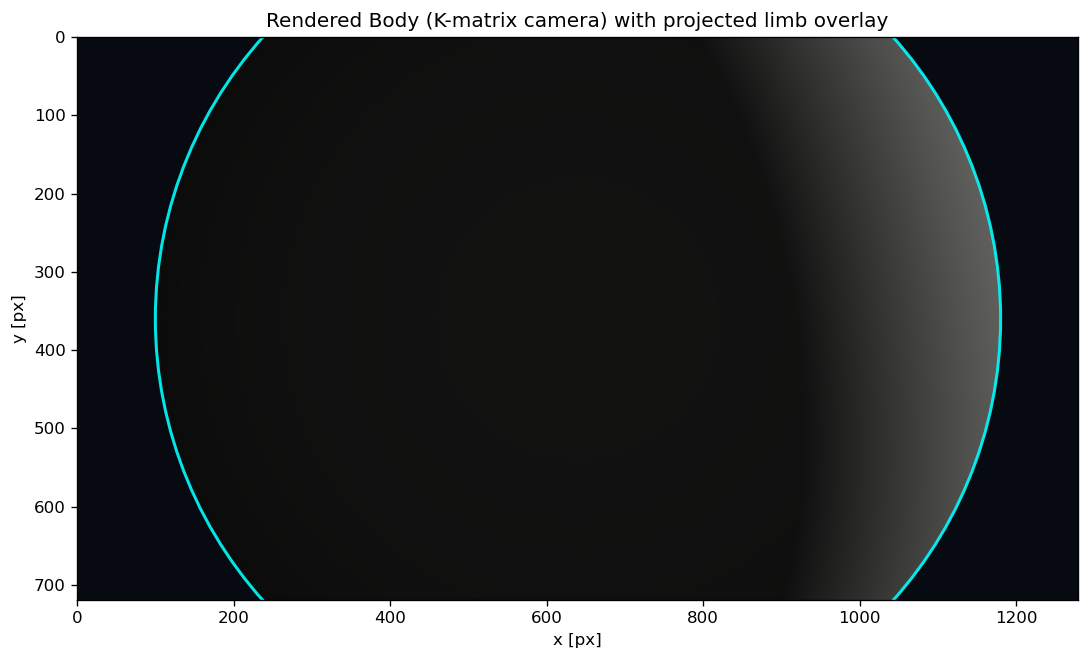

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

img = result.image
cx_px, cy_px = result.center_px
rx, ry = result.radius_px_x, result.radius_px_y

fig, ax = plt.subplots(figsize=(10, 5.6), dpi=120)
ax.imshow(img)

# Overlay projected limb as an ellipse from metadata.
limb = Ellipse(
    (cx_px, cy_px),
    width=2.0 * rx,
    height=2.0 * ry,
    fill=False,
    edgecolor="cyan",
    linewidth=1.8,
    alpha=0.9,
)
ax.add_patch(limb)

ax.set_title("Rendered Body (K-matrix camera) with projected limb overlay")
ax.set_xlim(0, img.shape[1] - 1)
ax.set_ylim(img.shape[0] - 1, 0)
ax.set_xlabel("x [px]")
ax.set_ylabel("y [px]")
plt.tight_layout()
plt.show()